<a href="https://colab.research.google.com/github/np03cs4s240220-spec/2438438_Surajkiran_Shrestha_AI/blob/main/2438438_SurajkiranShrestha_V.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Sign Classification with Convolutional Neural Networks
## 6CS012 - Final Integrated Assessment: Part II - Vision Task


## 1. Setup and Installation

In [5]:
# Install required packages
!pip install seaborn pillow --quiet

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# IMPORTANT: Run this cell first — all imports
import os
import time
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization,
                                      GlobalAveragePooling2D, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

print("All imports successful!")

TensorFlow version: 2.20.0
GPU Available: []
All imports successful!


## 2. Mount Drive, Setup Folders, Load Dataset

In [8]:

# ============================================================
# UPDATE THIS PATH to match YOUR Google Drive location
# ============================================================
ZIP_PATH = '/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/dataset/Traffic_Sign-20260508T172648Z-3-001.zip'

# Setup save directories
BASE_DIR = '/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task'
SAVE_DIR = f'{BASE_DIR}/figures'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{BASE_DIR}/notebook', exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs', exist_ok=True)

def save_plot(name):
    plt.savefig(f'{SAVE_DIR}/{name}.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {SAVE_DIR}/{name}.png")

# Unzip dataset
EXTRACT_DIR = '/content/traffic_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Find Train folder automatically
TRAIN_DIR = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'Train' in dirs:
        TRAIN_DIR = os.path.join(root, 'Train')
        break

print(f"Found Train directory at: {TRAIN_DIR}")

class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

Extracting dataset...
Found Train directory at: /content/traffic_data/Traffic_Sign/Train
Classes found: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Number of classes: 4


## 3. Clean Corrupted Images

In [9]:
# Deep clean - remove ALL corrupted/non-image files
removed = 0
total = 0

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        total += 1

        # Remove non-image files
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            print(f"Removing non-image: {fpath}")
            os.remove(fpath)
            removed += 1
            continue

        # Try to fully open and convert each image
        try:
            img = Image.open(fpath)
            img = img.convert('RGB')
            img.close()
        except Exception as e:
            print(f"Removing corrupt: {fpath}")
            os.remove(fpath)
            removed += 1

print(f"\nScanned {total} files, removed {removed} bad files")

# Verify clean counts
for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = len([f for f in os.listdir(class_path)])
    print(f"  {class_name}: {count} clean images")

Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00022_00001_00001.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00018_00023_00007.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00022_00000_00011.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00023_00009_00008.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00018_00031_00016.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00022_00012_00010.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Caution/00018_00031_00023.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Instructions/00035_00003_00001.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Instructions/00028_00007_00009.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Instructions/00028_00013_00012.png
Removing corrupt: /content/traffic_data/Traffic_Sign/Train/Instructions/00035_00019_00013.png
R

## 4. Dataset Statistics

In [10]:
# Dataset overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

total_images = 0
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = len([f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_counts[class_name] = count
    total_images += count
    print(f"  {class_name}: {count} images")

print(f"\nTotal Classes: {len(class_counts)}")
print(f"Total Images: {total_images}")
NUM_CLASSES = len(class_counts)

DATASET OVERVIEW
  Caution: 2422 images
  Instructions: 2841 images
  No Passing: 5362 images
  OverSpeed: 5242 images

Total Classes: 4
Total Images: 15867


### 4.1 Class Distribution Visualization

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/class_distribution.png


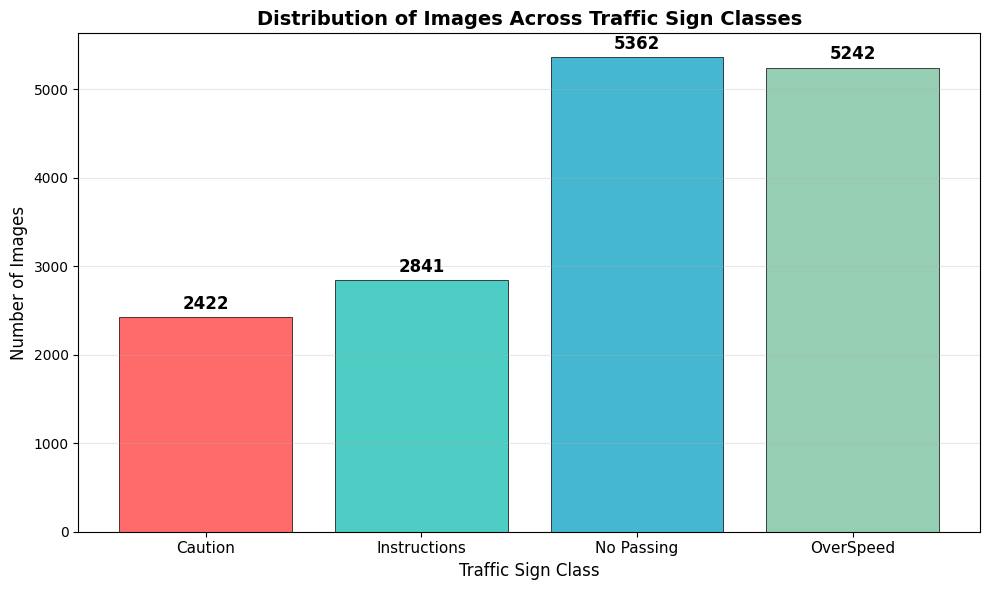


Class Balance Analysis:
  Caution: 2422 (45.17% of largest class)
  Instructions: 2841 (52.98% of largest class)
  No Passing: 5362 (100.00% of largest class)
  OverSpeed: 5242 (97.76% of largest class)


In [11]:
# Class distribution bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
               edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Distribution of Images Across Traffic Sign Classes', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Sign Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('class_distribution')
plt.show()

print("\nClass Balance Analysis:")
max_class = max(class_counts.values())
for name, count in class_counts.items():
    ratio = count / max_class
    print(f"  {name}: {count} ({ratio:.2%} of largest class)")

### 4.2 Sample Images from Each Class

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/sample_images.png


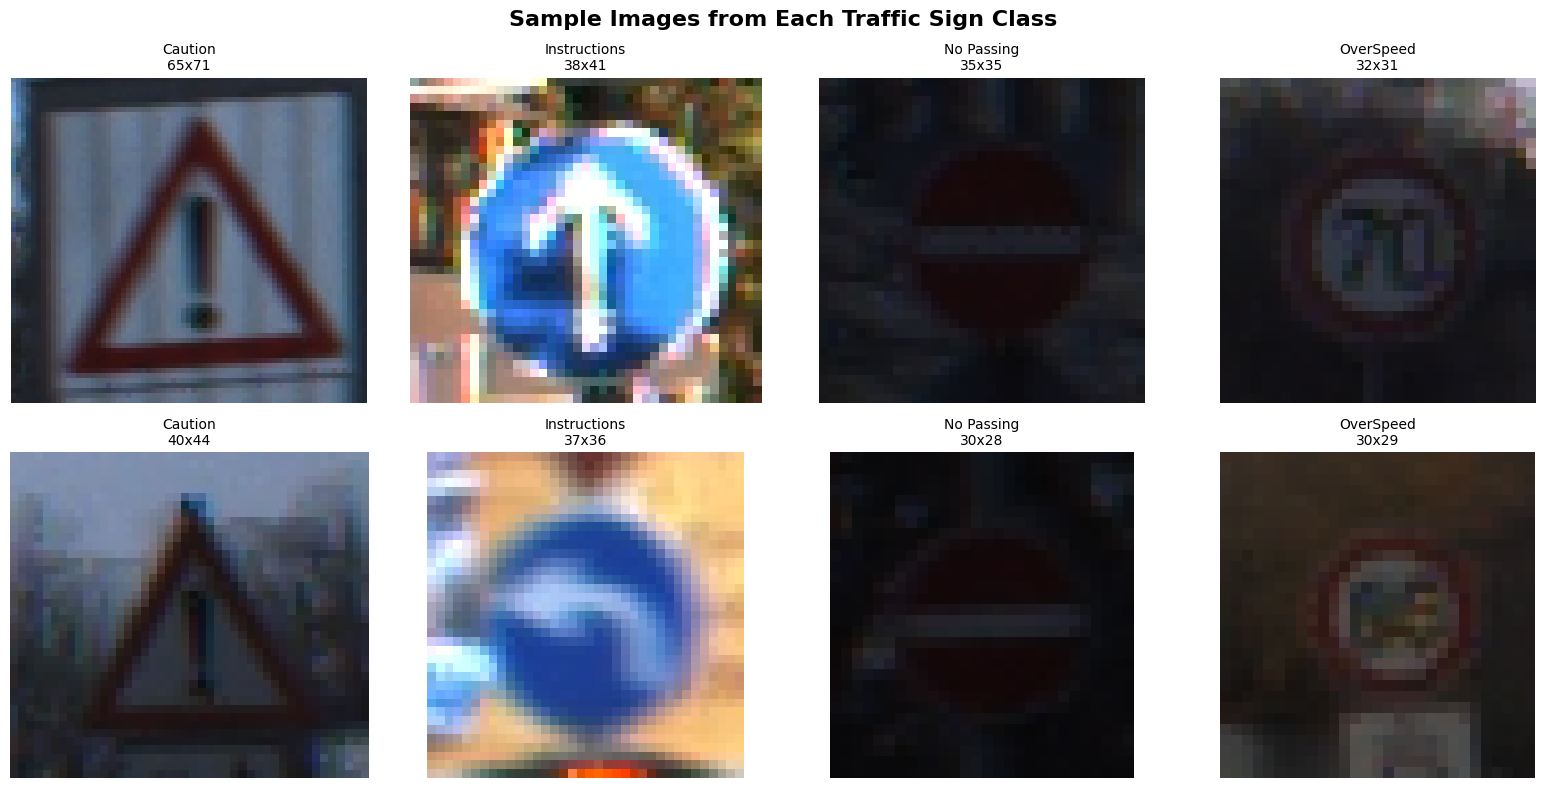

In [12]:
# Display sample images
fig, axes = plt.subplots(2, len(class_names), figsize=(4*len(class_names), 8))
fig.suptitle('Sample Images from Each Traffic Sign Class', fontsize=16, fontweight='bold')

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(TRAIN_DIR, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for row in range(2):
        img_path = os.path.join(class_path, images[row])
        img = plt.imread(img_path)
        axes[row, idx].imshow(img)
        axes[row, idx].set_title(f'{class_name}\n{img.shape[0]}x{img.shape[1]}', fontsize=10)
        axes[row, idx].axis('off')

plt.tight_layout()
save_plot('sample_images')
plt.show()

### 4.3 Image Size Analysis

In [13]:
# Analyze image sizes
widths = []
heights = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for img_name in os.listdir(class_path)[:100]:
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
        except:
            pass

print(f"Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.1f}")
print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")
print(f"\nAll images will be resized to 64x64 for model training.")

Width  - Min: 25, Max: 192, Mean: 49.7
Height - Min: 25, Max: 180, Mean: 48.9

All images will be resized to 64x64 for model training.


### 4.4 Data Preprocessing and Augmentation

In [14]:
# Data generators
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=15,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

NUM_CLASSES = train_generator.num_classes
print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class indices: {train_generator.class_indices}")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.

Training samples: 12695
Validation samples: 3172
Number of classes: 4
Class indices: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


### 4.5 Visualizing Augmented Images

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/augmented_images.png


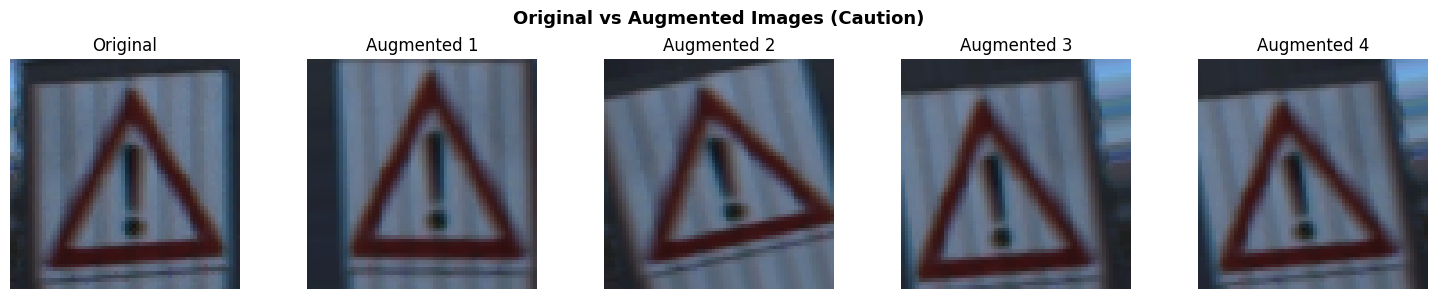

In [15]:
# Augmented image samples
sample_class = class_names[0]
sample_path = os.path.join(TRAIN_DIR, sample_class)
sample_imgs = [f for f in os.listdir(sample_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
sample_img_path = os.path.join(sample_path, sample_imgs[0])

img = load_img(sample_img_path, target_size=IMG_SIZE)
img_array = img_to_array(img).reshape(1, 64, 64, 3)

aug_gen = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1
)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Original vs Augmented Images ({sample_class})', fontsize=13, fontweight='bold')

axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 5):
    aug_img = next(aug_gen.flow(img_array, batch_size=1))[0] / 255.0
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.tight_layout()
save_plot('augmented_images')
plt.show()

---
## Part A: CNNs from Scratch

## 5. Baseline CNN Model


In [16]:
# Build Baseline CNN (reduced complexity to avoid overfitting)
def build_baseline_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),

        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

print("=" * 60)
print("BASELINE MODEL SUMMARY")
print("=" * 60)
baseline_model.summary()

BASELINE MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,152,420 (4.40 MB)

 Trainable params: 1,152,420 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

### 5.1 Train Baseline Model

In [17]:
# Helper function for plotting training curves
def plot_training_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title(f'{model_name} - Loss over Epochs', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title(f'{model_name} - Accuracy over Epochs', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_plot(f'{model_name.replace(" ", "_").lower()}_training_curves')
    plt.show()

# Evaluation function
def evaluate_model(model, generator, model_name):
    generator.reset()
    predictions = model.predict(generator, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = generator.classes
    class_labels = list(generator.class_indices.keys())

    accuracy = np.mean(predicted_classes == true_classes)
    print(f"\n{'='*60}")
    print(f"{model_name} - EVALUATION RESULTS")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print(f"\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels))

    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    save_plot(f'{model_name.replace(" ", "_").lower()}_confusion_matrix')
    plt.show()

    return accuracy, predictions, predicted_classes, true_classes

# Sample predictions function
def show_sample_predictions(model, generator, model_name):
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images, verbose=0)
    class_labels = list(generator.class_indices.keys())

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{model_name} - Sample Predictions', fontsize=15, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            ax.imshow(images[i])
            pred_class = class_labels[np.argmax(predictions[i])]
            true_class = class_labels[np.argmax(labels[i])]
            confidence = np.max(predictions[i])
            color = 'green' if pred_class == true_class else 'red'
            ax.set_title(f'True: {true_class}\nPred: {pred_class} ({confidence:.1%})',
                        fontsize=9, color=color, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    save_plot(f'{model_name.replace(" ", "_").lower()}_sample_predictions')
    plt.show()

In [18]:
# Train baseline model
EPOCHS = 30
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training Baseline Model...")
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop], verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline Training Time: {baseline_train_time:.1f} seconds")

Training Baseline Model...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 169s 419ms/step - accuracy: 0.8502 - loss: 0.3648 - val_accuracy: 0.8045 - val_loss: 2.1999
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 154s 387ms/step - accuracy: 0.9802 - loss: 0.0625 - val_accuracy: 0.7856 - val_loss: 3.1334
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 154s 387ms/step - accuracy: 0.9897 - loss: 0.0300 - val_accuracy: 0.8194 - val_loss: 2.9416
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 156s 393ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.8042 - val_loss: 3.8333
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 150s 378ms/step - accuracy: 0.9959 - loss: 0.0132 - val_accuracy: 0.8231 - val_loss: 4.6722
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 203s 379ms/step - accuracy: 0.9938 - loss: 0.0229 - val_accuracy: 0.8209 - val_loss: 4.3659

Baseline Training Time: 985.2 seconds


### 5.2 Baseline Training Curves

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_cnn_training_curves.png


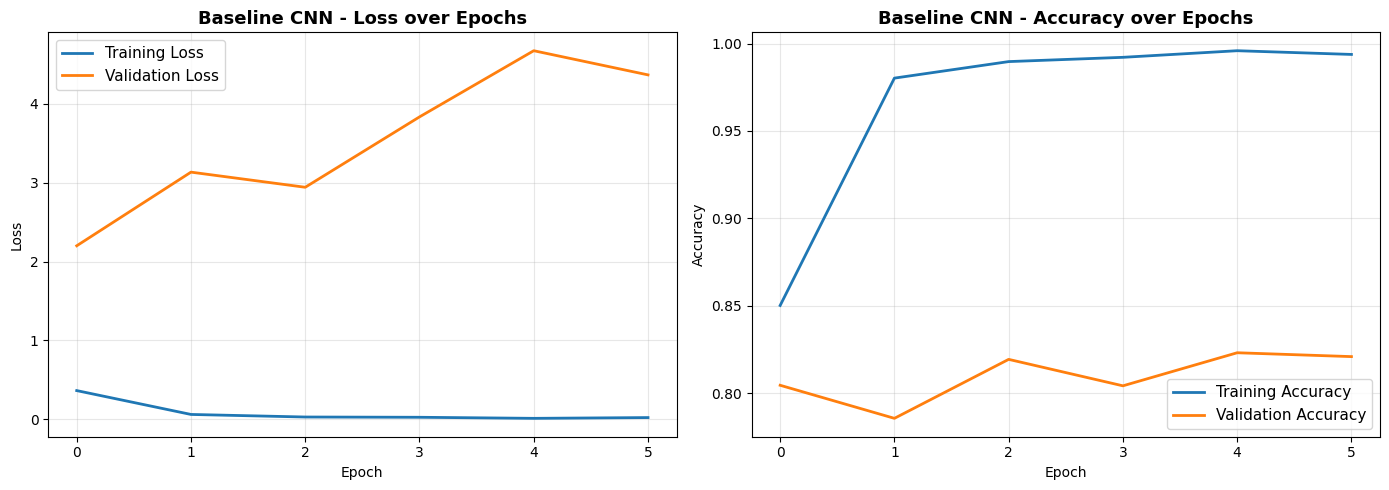

In [19]:
plot_training_curves(history_baseline, 'Baseline CNN')

### 5.3 Baseline Evaluation


Baseline CNN - EVALUATION RESULTS
Overall Accuracy: 0.8045 (80.45%)

Classification Report:
              precision    recall  f1-score   support

     Caution       0.47      0.98      0.64       484
Instructions       0.90      0.08      0.15       568
  No Passing       0.97      0.95      0.96      1072
   OverSpeed       0.95      0.97      0.96      1048

    accuracy                           0.80      3172
   macro avg       0.82      0.74      0.68      3172
weighted avg       0.87      0.80      0.76      3172

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_cnn_confusion_matrix.png


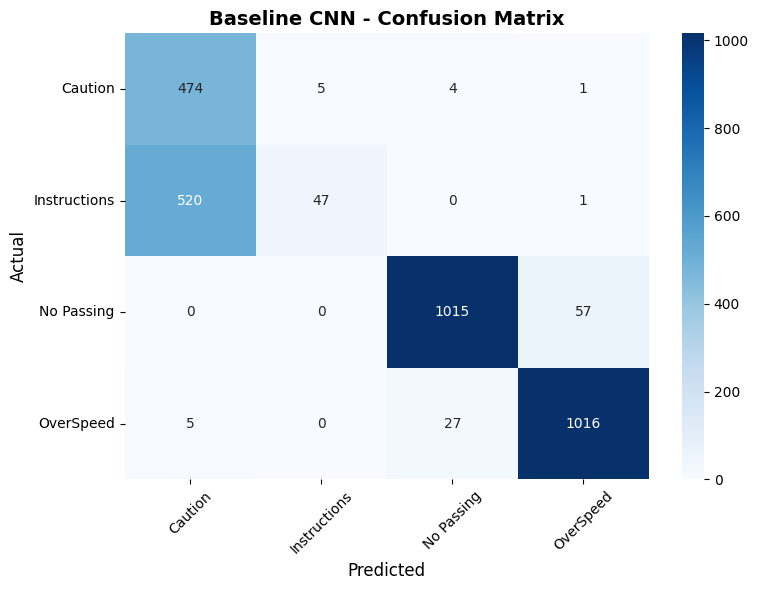

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_cnn_sample_predictions.png


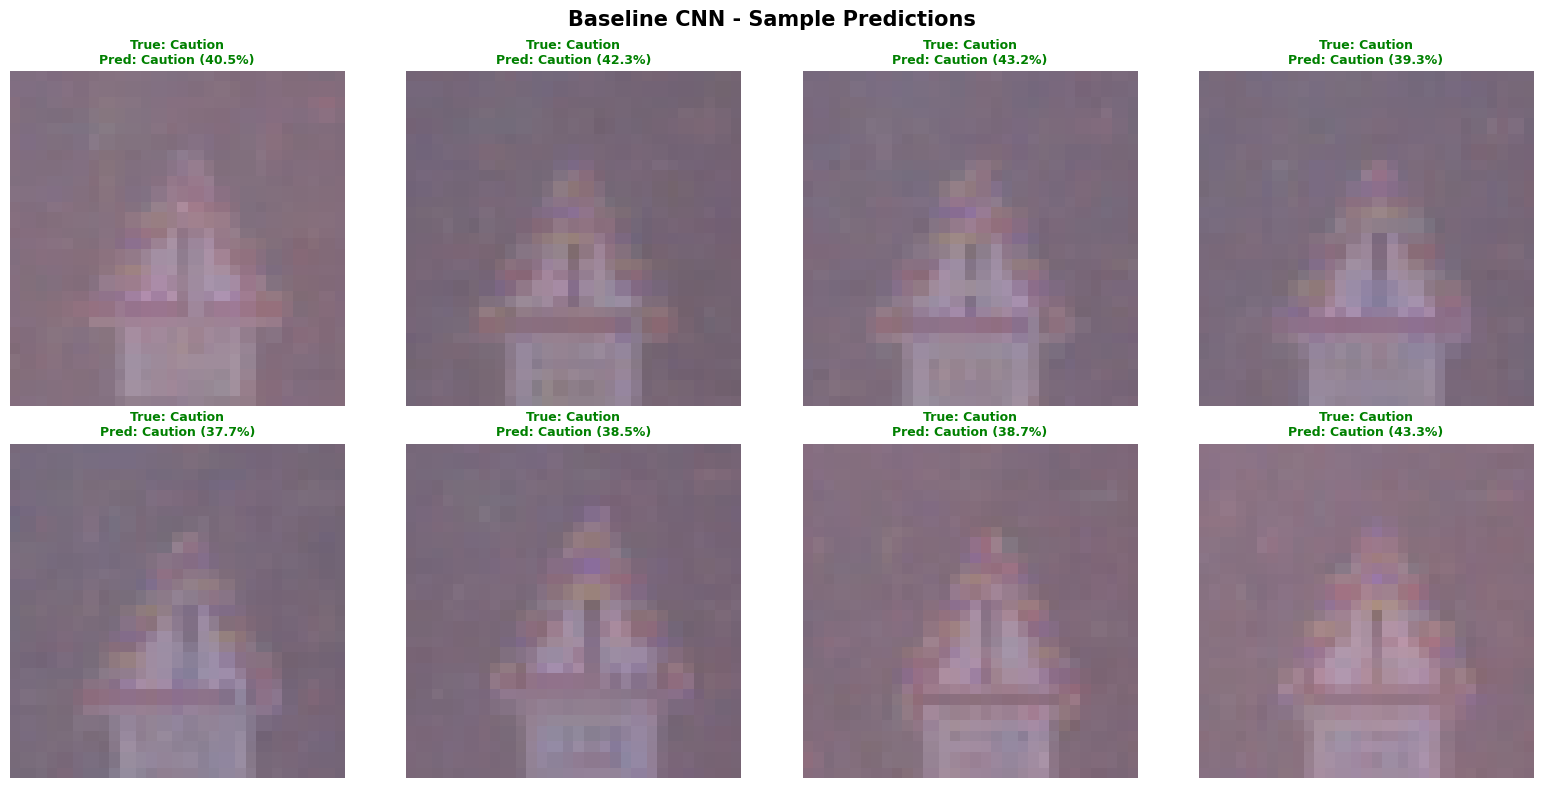

In [20]:
baseline_acc, baseline_preds, baseline_pred_classes, true_classes = evaluate_model(
    baseline_model, val_generator, 'Baseline CNN'
)
show_sample_predictions(baseline_model, val_generator, 'Baseline CNN')

---
## 6. Deeper Architecture with Regularization


In [21]:
# Deeper CNN with regularization (reduced complexity)
def build_deeper_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.4),

        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

deeper_model = build_deeper_model()
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

print("=" * 60)
print("DEEPER MODEL SUMMARY")
print("=" * 60)
deeper_model.summary()

print(f"\nBaseline Parameters: {baseline_model.count_params():,}")
print(f"Deeper Parameters:  {deeper_model.count_params():,}")

DEEPER MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,170,948 (4.47 MB)

 Trainable params: 1,169,220 (4.46 MB)

 Non-trainable params: 1,728 (6.75 KB)


Baseline Parameters: 1,152,420
Deeper Parameters:  1,170,948


### 6.1 Train Deeper Model

In [22]:
# Train deeper model
print("Training Deeper Model with Regularization...")
start_time = time.time()

history_deeper = deeper_model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop], verbose=1
)

deeper_train_time = time.time() - start_time
print(f"\nDeeper Model Training Time: {deeper_train_time:.1f} seconds")
print(f"Baseline Training Time:     {baseline_train_time:.1f} seconds")

Training Deeper Model with Regularization...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 270s 664ms/step - accuracy: 0.8506 - loss: 0.3981 - val_accuracy: 0.4458 - val_loss: 1.9738
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 259s 651ms/step - accuracy: 0.9758 - loss: 0.0824 - val_accuracy: 0.7210 - val_loss: 2.6192
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 258s 651ms/step - accuracy: 0.9861 - loss: 0.0485 - val_accuracy: 0.8121 - val_loss: 3.3933
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 263s 654ms/step - accuracy: 0.9870 - loss: 0.0477 - val_accuracy: 0.7992 - val_loss: 3.2530
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 269s 673ms/step - accuracy: 0.9931 - loss: 0.0289 - val_accuracy: 0.8127 - val_loss: 2.9312
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 264s 665ms/step - accuracy: 0.9927 - loss: 0.0261 - val_accuracy: 0.8105 - val_loss: 3.1455

Deeper Model Training Time: 1583.6 seconds
Baseline Training Time:     985.2 seconds


### 6.2 Deeper Model Training Curves

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_cnn_training_curves.png


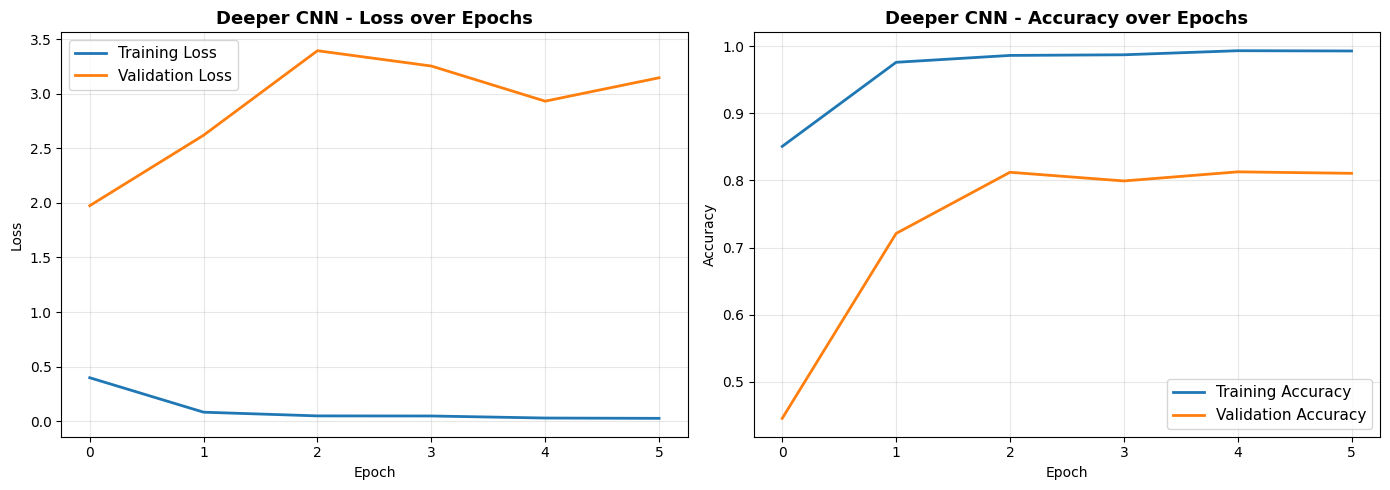

In [23]:
plot_training_curves(history_deeper, 'Deeper CNN')

### 6.3 Deeper Model Evaluation


Deeper CNN - EVALUATION RESULTS
Overall Accuracy: 0.4458 (44.58%)

Classification Report:
              precision    recall  f1-score   support

     Caution       0.40      0.27      0.32       484
Instructions       0.35      0.08      0.12       568
  No Passing       0.92      0.23      0.36      1072
   OverSpeed       0.41      0.95      0.57      1048

    accuracy                           0.45      3172
   macro avg       0.52      0.38      0.34      3172
weighted avg       0.57      0.45      0.38      3172

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_cnn_confusion_matrix.png


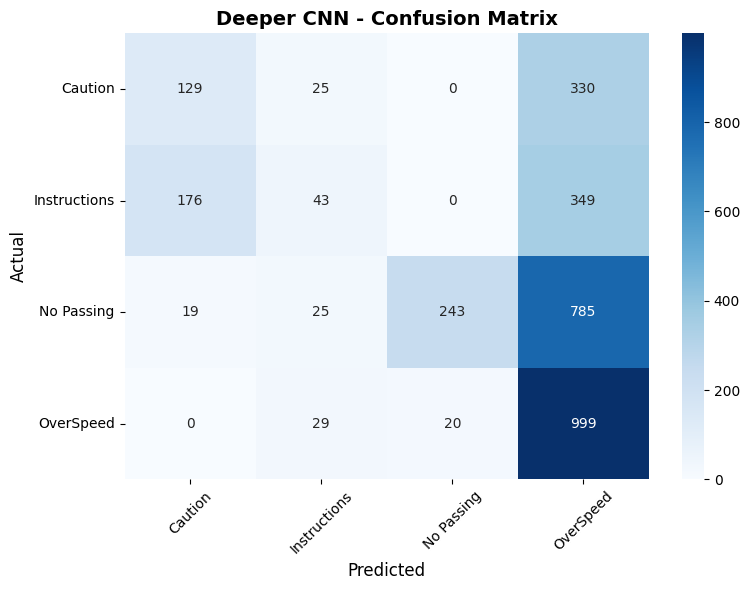

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_cnn_sample_predictions.png


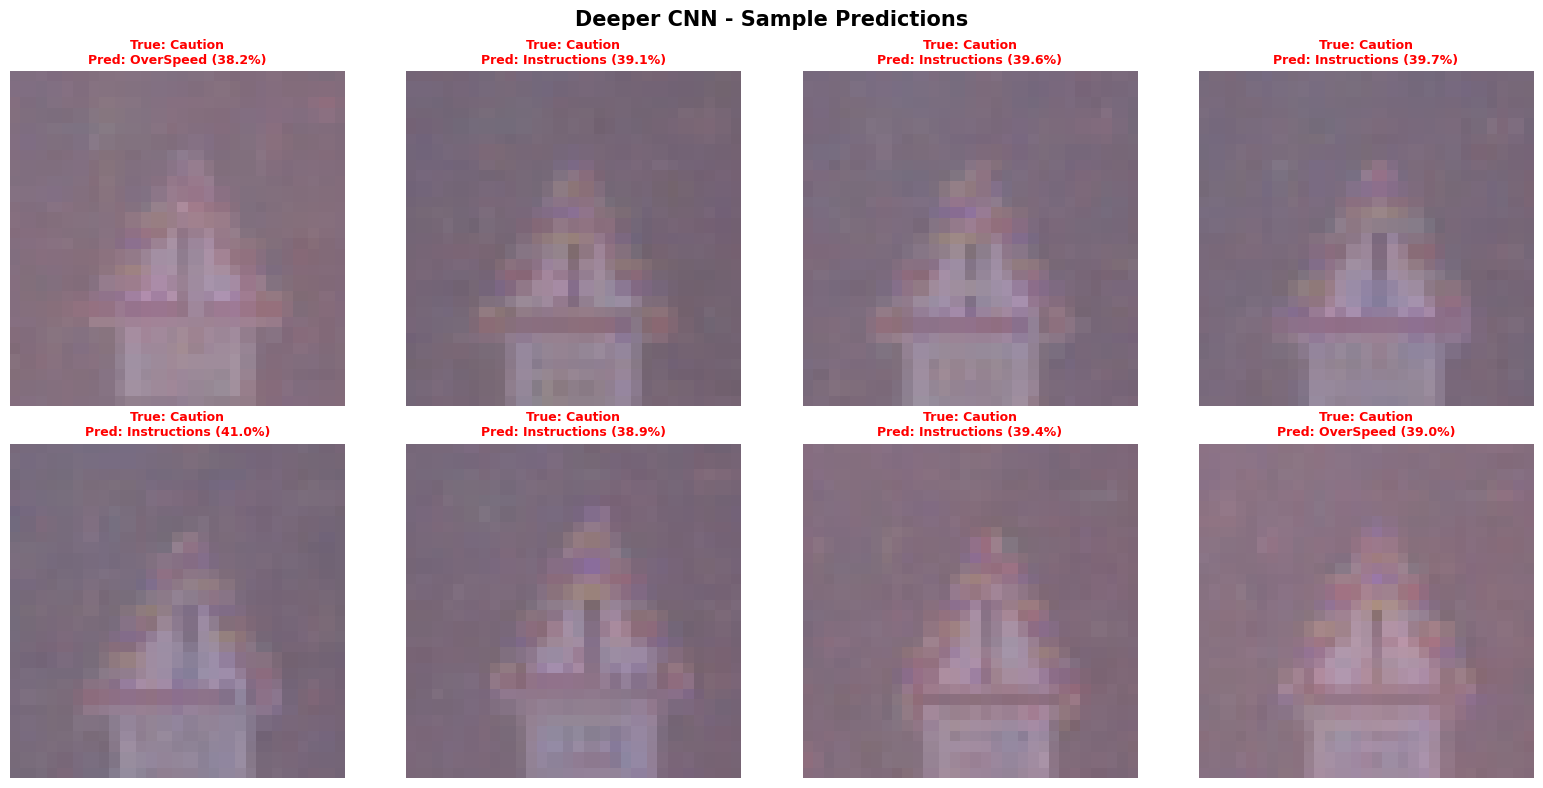

In [24]:
deeper_acc, deeper_preds, deeper_pred_classes, _ = evaluate_model(
    deeper_model, val_generator, 'Deeper CNN'
)
show_sample_predictions(deeper_model, val_generator, 'Deeper CNN')

---
## 7. Experimentation and Comparative Analysis

### 7.1 Baseline vs Deeper Model


COMPARATIVE ANALYSIS: BASELINE vs DEEPER MODEL
Metric                                Baseline          Deeper
------------------------------------------------------------
Final Val Accuracy                      0.8209          0.8105
Final Val Loss                          4.3659          3.1455
Training Time (s)                        985.2          1583.6
Total Parameters                     1,152,420       1,170,948
Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_vs_deeper_comparison.png


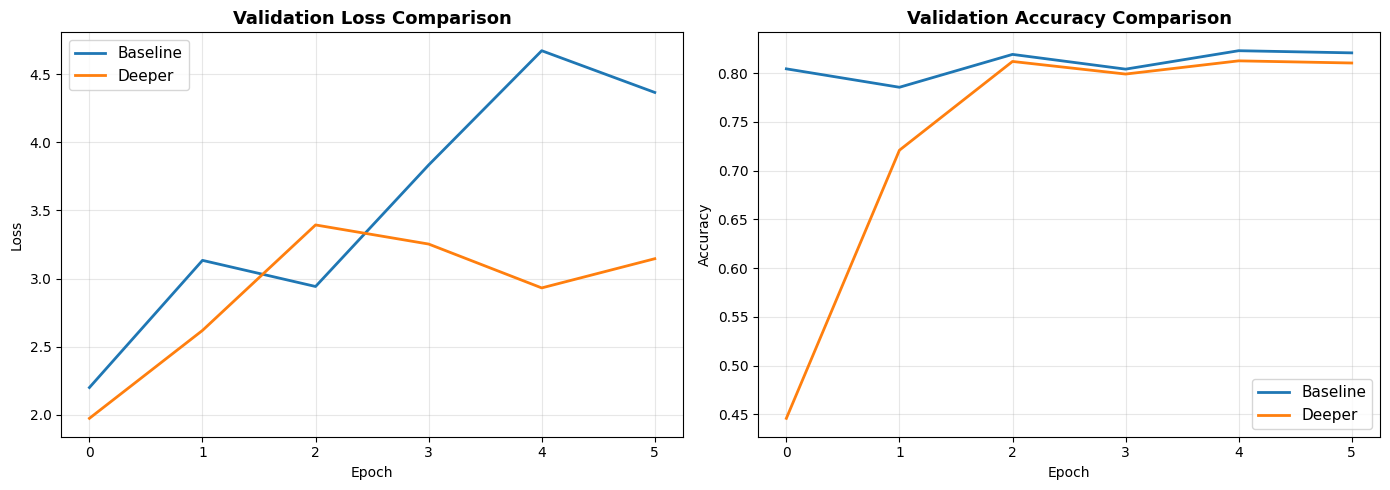

In [25]:
# Comparative analysis
print("=" * 60)
print("COMPARATIVE ANALYSIS: BASELINE vs DEEPER MODEL")
print("=" * 60)

print(f"{'Metric':<30} {'Baseline':>15} {'Deeper':>15}")
print("-" * 60)
print(f"{'Final Val Accuracy':<30} {history_baseline.history['val_accuracy'][-1]:>15.4f} {history_deeper.history['val_accuracy'][-1]:>15.4f}")
print(f"{'Final Val Loss':<30} {history_baseline.history['val_loss'][-1]:>15.4f} {history_deeper.history['val_loss'][-1]:>15.4f}")
print(f"{'Training Time (s)':<30} {baseline_train_time:>15.1f} {deeper_train_time:>15.1f}")
print(f"{'Total Parameters':<30} {baseline_model.count_params():>15,} {deeper_model.count_params():>15,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_baseline.history['val_loss'], label='Baseline', linewidth=2)
ax1.plot(history_deeper.history['val_loss'], label='Deeper', linewidth=2)
ax1.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history_baseline.history['val_accuracy'], label='Baseline', linewidth=2)
ax2.plot(history_deeper.history['val_accuracy'], label='Deeper', linewidth=2)
ax2.set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('baseline_vs_deeper_comparison')
plt.show()

### 7.2 Optimizer Analysis: SGD vs Adam

Training Deeper Model with SGD Optimizer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 266s 657ms/step - accuracy: 0.7367 - loss: 0.6313 - val_accuracy: 0.4515 - val_loss: 3.3787
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 260s 654ms/step - accuracy: 0.9602 - loss: 0.1318 - val_accuracy: 0.6895 - val_loss: 2.4948
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 257s 646ms/step - accuracy: 0.9805 - loss: 0.0742 - val_accuracy: 0.7352 - val_loss: 2.9164
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 255s 641ms/step - accuracy: 0.9877 - loss: 0.0453 - val_accuracy: 0.8115 - val_loss: 2.7233
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 258s 650ms/step - accuracy: 0.9880 - loss: 0.0448 - val_accuracy: 0.7743 - val_loss: 2.8924

Training Deeper Model with Adam Optimizer...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 266s 654ms/step - accuracy: 0.8414 - loss: 0.4221 - val_accuracy: 0.7298 - val_loss: 1.4755
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 260s 654ms/step - accuracy: 0.9806 - loss: 0.0734 - val_accuracy: 0.7418 - val_loss: 1.5534
Epoch 3/30
397/397 ━━━━━━━━━━━

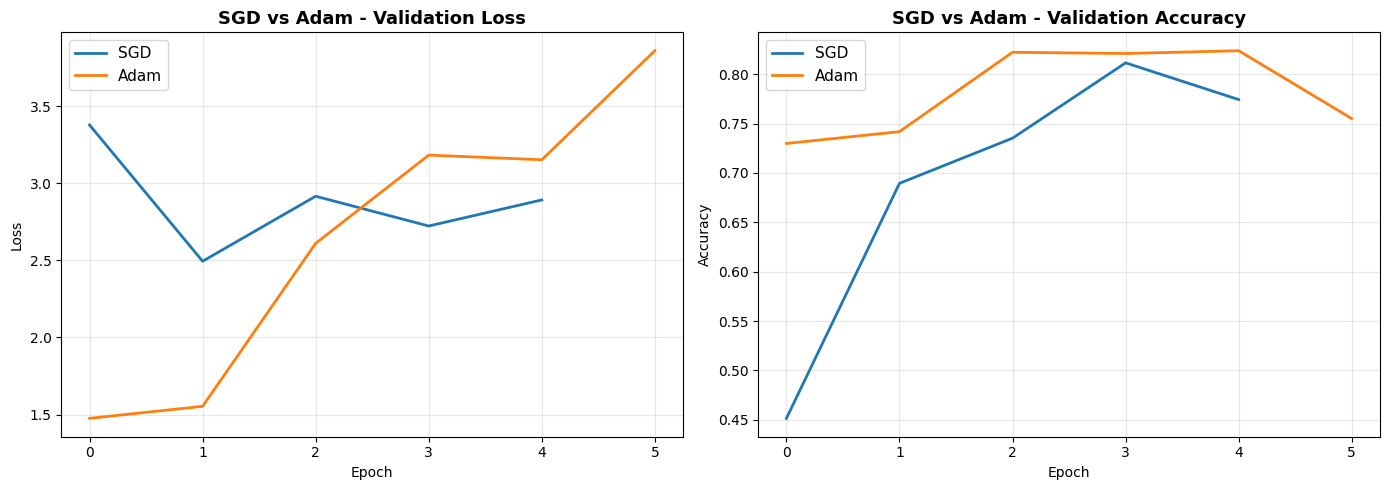

In [26]:
# SGD vs Adam
print("Training Deeper Model with SGD Optimizer...")
deeper_sgd = build_deeper_model()
deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy', metrics=['accuracy']
)

start_time = time.time()
history_sgd = deeper_sgd.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop], verbose=1
)
sgd_time = time.time() - start_time

print("\nTraining Deeper Model with Adam Optimizer...")
deeper_adam = build_deeper_model()
deeper_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

start_time = time.time()
history_adam = deeper_adam.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop], verbose=1
)
adam_time = time.time() - start_time

print(f"\n{'='*60}")
print("OPTIMIZER COMPARISON: SGD vs Adam")
print(f"{'='*60}")
print(f"SGD  - Val Accuracy: {history_sgd.history['val_accuracy'][-1]:.4f}, Time: {sgd_time:.1f}s")
print(f"Adam - Val Accuracy: {history_adam.history['val_accuracy'][-1]:.4f}, Time: {adam_time:.1f}s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_sgd.history['val_loss'], label='SGD', linewidth=2)
ax1.plot(history_adam.history['val_loss'], label='Adam', linewidth=2)
ax1.set_title('SGD vs Adam - Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history_sgd.history['val_accuracy'], label='SGD', linewidth=2)
ax2.plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
ax2.set_title('SGD vs Adam - Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('sgd_vs_adam_comparison')
plt.show()

### 7.3 Ablation Study: Removing Dropout

Training Deeper Model WITHOUT Dropout (Ablation Study)...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 265s 653ms/step - accuracy: 0.9155 - loss: 0.2253 - val_accuracy: 0.7018 - val_loss: 0.9678
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 262s 655ms/step - accuracy: 0.9857 - loss: 0.0432 - val_accuracy: 0.8039 - val_loss: 1.9979
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 259s 653ms/step - accuracy: 0.9883 - loss: 0.0391 - val_accuracy: 0.7872 - val_loss: 2.4343
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 267s 673ms/step - accuracy: 0.9927 - loss: 0.0247 - val_accuracy: 0.8175 - val_loss: 2.1886
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 261s 657ms/step - accuracy: 0.9965 - loss: 0.0132 - val_accuracy: 0.8080 - val_loss: 2.8429
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 266s 671ms/step - accuracy: 0.9931 - loss: 0.0201 - val_accuracy: 0.7976 - val_loss: 2.3202

ABLATION STUDY: Effect of Removing Dropout
With Dropout    - Val Accuracy: 0.8105
Without Dropout - Val Accuracy: 0.7976
Saved: /content/drive/MyDriv

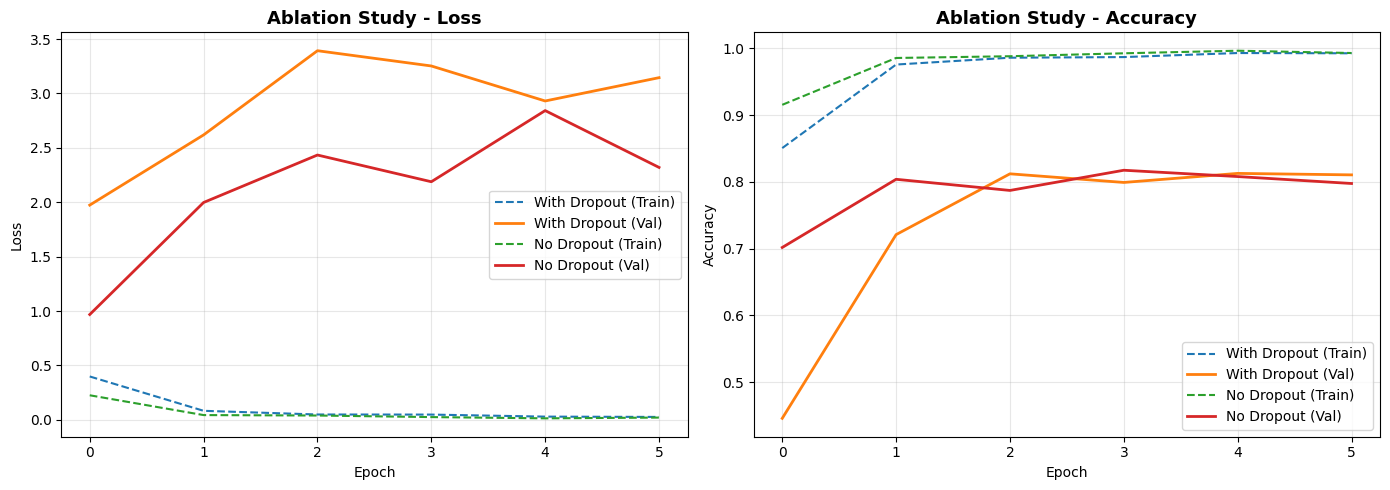

In [27]:
# Ablation: Deeper model WITHOUT Dropout
def build_deeper_no_dropout():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

print("Training Deeper Model WITHOUT Dropout (Ablation Study)...")
ablation_model = build_deeper_no_dropout()
ablation_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

start_time = time.time()
history_ablation = ablation_model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop], verbose=1
)
ablation_time = time.time() - start_time

print(f"\n{'='*60}")
print("ABLATION STUDY: Effect of Removing Dropout")
print(f"{'='*60}")
print(f"With Dropout    - Val Accuracy: {history_deeper.history['val_accuracy'][-1]:.4f}")
print(f"Without Dropout - Val Accuracy: {history_ablation.history['val_accuracy'][-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_deeper.history['loss'], label='With Dropout (Train)', linestyle='--')
ax1.plot(history_deeper.history['val_loss'], label='With Dropout (Val)', linewidth=2)
ax1.plot(history_ablation.history['loss'], label='No Dropout (Train)', linestyle='--')
ax1.plot(history_ablation.history['val_loss'], label='No Dropout (Val)', linewidth=2)
ax1.set_title('Ablation Study - Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_deeper.history['accuracy'], label='With Dropout (Train)', linestyle='--')
ax2.plot(history_deeper.history['val_accuracy'], label='With Dropout (Val)', linewidth=2)
ax2.plot(history_ablation.history['accuracy'], label='No Dropout (Train)', linestyle='--')
ax2.plot(history_ablation.history['val_accuracy'], label='No Dropout (Val)', linewidth=2)
ax2.set_title('Ablation Study - Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('ablation_study_dropout')
plt.show()

### 7.4 Results Summary (Part A)

In [28]:
# Summary
print("=" * 70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 70)
print(f"{'Model':<30} {'Val Accuracy':>15} {'Val Loss':>12} {'Train Time':>12}")
print("-" * 70)
print(f"{'Baseline CNN':<30} {history_baseline.history['val_accuracy'][-1]:>15.4f} {history_baseline.history['val_loss'][-1]:>12.4f} {baseline_train_time:>10.1f}s")
print(f"{'Deeper CNN (Adam)':<30} {history_deeper.history['val_accuracy'][-1]:>15.4f} {history_deeper.history['val_loss'][-1]:>12.4f} {deeper_train_time:>10.1f}s")
print(f"{'Deeper CNN (SGD)':<30} {history_sgd.history['val_accuracy'][-1]:>15.4f} {history_sgd.history['val_loss'][-1]:>12.4f} {sgd_time:>10.1f}s")
print(f"{'Deeper CNN (No Dropout)':<30} {history_ablation.history['val_accuracy'][-1]:>15.4f} {history_ablation.history['val_loss'][-1]:>12.4f} {ablation_time:>10.1f}s")
print("-" * 70)

print("\nOverfitting Analysis:")
for name, h in [('Baseline', history_baseline), ('Deeper', history_deeper)]:
    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    status = "Overfitting" if gap > 0.1 else "Slight Overfitting" if gap > 0.05 else "Good Fit"
    print(f"  {name}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f} -> {status}")

print(f"\nHardware: {'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'}")

COMPREHENSIVE RESULTS SUMMARY
Model                             Val Accuracy     Val Loss   Train Time
----------------------------------------------------------------------
Baseline CNN                            0.8209       4.3659      985.2s
Deeper CNN (Adam)                       0.8105       3.1455     1583.6s
Deeper CNN (SGD)                        0.7743       2.8924     1295.2s
Deeper CNN (No Dropout)                 0.7976       2.3202     1580.7s
----------------------------------------------------------------------

Overfitting Analysis:
  Baseline: Train=0.9938, Val=0.8209, Gap=0.1728 -> Overfitting
  Deeper: Train=0.9927, Val=0.8105, Gap=0.1821 -> Overfitting

Hardware: CPU


---
## Part B: Transfer Learning with MobileNetV2

### 8.1 Create 224x224 Data Generators


In [29]:
# Clean images again for transfer learning generators
removed = 0
for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            os.remove(fpath)
            removed += 1
            continue
        try:
            img = Image.open(fpath)
            img = img.convert('RGB')
            img.close()
        except:
            os.remove(fpath)
            removed += 1
if removed > 0:
    print(f"Cleaned {removed} additional bad files")

# Create 224x224 generators for MobileNetV2
IMG_SIZE_TL = (224, 224)

train_datagen_tl = ImageDataGenerator(
    rescale=1./255, rotation_range=15,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, validation_split=0.2
)

val_datagen_tl = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)

val_gen_tl = val_datagen_tl.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

print(f"Training: {train_gen_tl.samples} | Validation: {val_gen_tl.samples}")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Training: 12695 | Validation: 3172


### 8.2 Build MobileNetV2 Transfer Learning Model

In [30]:
# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = Model(inputs=inputs, outputs=outputs)

print("=" * 60)
print("TRANSFER LEARNING MODEL (MobileNetV2) SUMMARY")
print("=" * 60)
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TRANSFER LEARNING MODEL (MobileNetV2) SUMMARY


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 8.3 Phase 1: Feature Extraction

In [31]:
# Phase 1: Feature Extraction (frozen base)
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

print("Phase 1: Feature Extraction (base frozen)...")
start_time = time.time()

history_transfer_p1 = transfer_model.fit(
    train_gen_tl, epochs=10,
    validation_data=val_gen_tl,
    callbacks=[early_stop], verbose=1
)

transfer_p1_time = time.time() - start_time
print(f"Phase 1 Time: {transfer_p1_time:.1f}s")

Phase 1: Feature Extraction (base frozen)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 864s 2s/step - accuracy: 0.7408 - loss: 0.6366 - val_accuracy: 0.6737 - val_loss: 1.7420
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 855s 2s/step - accuracy: 0.9101 - loss: 0.2437 - val_accuracy: 0.7264 - val_loss: 1.9529
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.9357 - loss: 0.1736 - val_accuracy: 0.7516 - val_loss: 2.1935
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.9521 - loss: 0.1350 - val_accuracy: 0.7607 - val_loss: 2.3470
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 851s 2s/step - accuracy: 0.9601 - loss: 0.1129 - val_accuracy: 0.7629 - val_loss: 2.6703
Phase 1 Time: 4266.5s


### 8.4 Phase 2: Fine-Tuning

In [ ]:
# Phase 2: Fine-tune last 20 layers
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

print("Phase 2: Fine-Tuning (last 20 layers unfrozen)...")
start_time = time.time()

history_transfer_p2 = transfer_model.fit(
    train_gen_tl, epochs=10,
    validation_data=val_gen_tl,
    callbacks=[early_stop], verbose=1
)

transfer_p2_time = time.time() - start_time
print(f"Phase 2 Time: {transfer_p2_time:.1f}s")
print(f"Total Transfer Learning Time: {transfer_p1_time + transfer_p2_time:.1f}s")

Phase 2: Fine-Tuning (last 20 layers unfrozen)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 1063s 3s/step - accuracy: 0.9410 - loss: 0.1705 - val_accuracy: 0.7733 - val_loss: 2.2267
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 1015s 3s/step - accuracy: 0.9610 - loss: 0.1106 - val_accuracy: 0.7822 - val_loss: 2.2801
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 1011s 3s/step - accuracy: 0.9737 - loss: 0.0768 - val_accuracy: 0.7900 - val_loss: 2.3763
Epoch 4/10
153/397 ━━━━━━━━━━━━━━━━━━━━ 8:54 2s/step - accuracy: 0.9721 - loss: 0.0743

### 8.5 Transfer Learning Evaluation


MobileNetV2 Transfer - EVALUATION RESULTS
Overall Accuracy: 0.7393 (73.93%)

Classification Report:
              precision    recall  f1-score   support

     Caution       0.46      0.90      0.61       484
Instructions       0.93      0.02      0.04       568
  No Passing       0.90      0.86      0.88      1072
   OverSpeed       0.83      0.93      0.88      1048

    accuracy                           0.74      3172
   macro avg       0.78      0.68      0.60      3172
weighted avg       0.81      0.74      0.69      3172

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/mobilenetv2_transfer_confusion_matrix.png


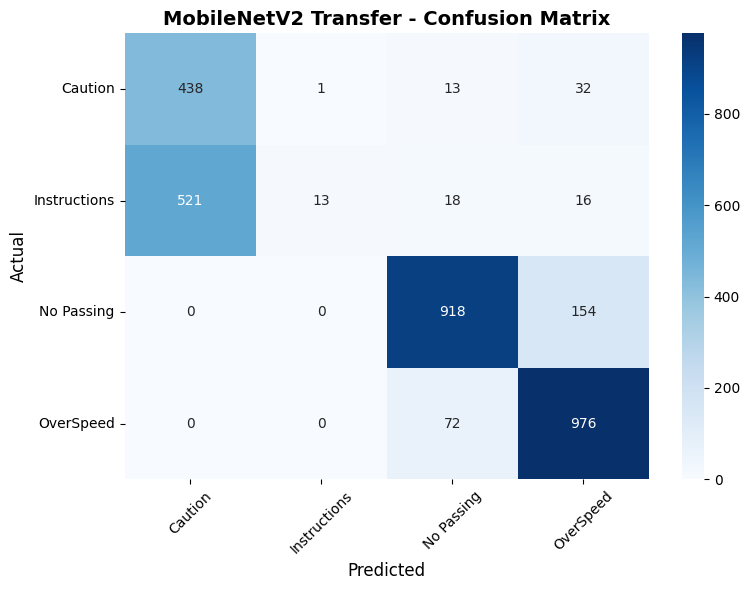

Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/transfer_learning_curves.png


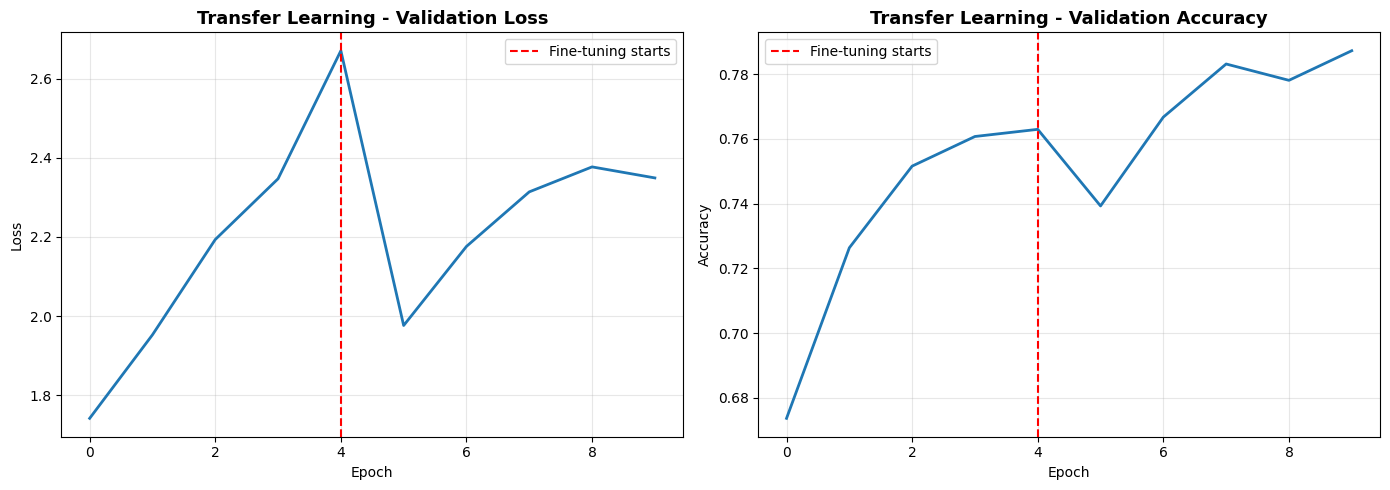

In [33]:
# Evaluate transfer model
transfer_acc, transfer_preds, transfer_pred_classes, _ = evaluate_model(
    transfer_model, val_gen_tl, 'MobileNetV2 Transfer'
)

# Combined training curves
combined_loss = history_transfer_p1.history['val_loss'] + history_transfer_p2.history['val_loss']
combined_acc = history_transfer_p1.history['val_accuracy'] + history_transfer_p2.history['val_accuracy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(combined_loss, linewidth=2)
ax1.axvline(x=len(history_transfer_p1.history['val_loss'])-1, color='r',
            linestyle='--', label='Fine-tuning starts')
ax1.set_title('Transfer Learning - Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(combined_acc, linewidth=2)
ax2.axvline(x=len(history_transfer_p1.history['val_accuracy'])-1, color='r',
            linestyle='--', label='Fine-tuning starts')
ax2.set_title('Transfer Learning - Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('transfer_learning_curves')
plt.show()

### 8.6 Final Comparison: All Models

FINAL MODEL COMPARISON: Scratch vs Transfer Learning
  Baseline CNN             : 0.8209 (82.09%)
  Deeper CNN               : 0.8105 (81.05%)
  MobileNetV2              : 0.7872 (78.72%)
Saved: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/final_model_comparison.png


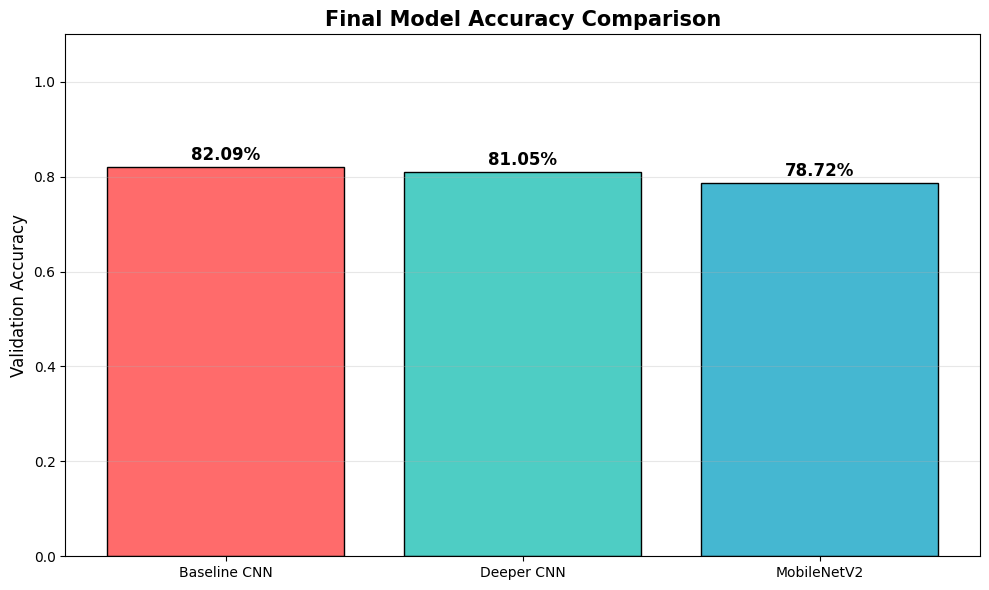


Best performing model: Baseline CNN


In [34]:
# Final comparison
print("=" * 70)
print("FINAL MODEL COMPARISON: Scratch vs Transfer Learning")
print("=" * 70)

final_results = {
    'Baseline CNN': history_baseline.history['val_accuracy'][-1],
    'Deeper CNN': history_deeper.history['val_accuracy'][-1],
    'MobileNetV2': combined_acc[-1]
}

for model_name, acc in final_results.items():
    print(f"  {model_name:25s}: {acc:.4f} ({acc*100:.2f}%)")

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(final_results.keys(), final_results.values(), color=colors, edgecolor='black')

for bar, acc in zip(bars, final_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Final Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('final_model_comparison')
plt.show()

best_model = max(final_results, key=final_results.get)
print(f"\nBest performing model: {best_model}")